# 03 - Evaluación y Comparación de Modelos
## Tipo de cambio USD/PYG

Cálculo de métricas (RMSE, MAE, MAPE, sMAPE, MASE, R²), visualizaciones de
predicciones vs valores reales, comparación entre modelos y análisis de
residuales. **Ambos modelos pronostican el mismo horizonte (60 días) de
forma recursiva/estática, sin usar valores reales futuros — comparación
justa** (ver notebook 02 para el detalle de esta corrección metodológica).


In [1]:
# Clonar el repo para que las rutas relativas (../data/..., ../results/...)
# funcionen correctamente al abrir este notebook desde Colab/GitHub.
!git clone https://github.com/CANM17/proyecto-ts-tipocambio.git
%cd proyecto-ts-tipocambio/notebooks

Cloning into 'proyecto-ts-tipocambio'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 44 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 1.07 MiB | 11.07 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/proyecto-ts-tipocambio/notebooks


In [2]:
DATE_COL = "fecha"
TARGET_COL = "tipo_cambio"


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams["figure.figsize"] = (11, 4)

res = pd.read_csv("../results/predicciones.csv", parse_dates=[DATE_COL])
res.head()


,fecha,tipo_cambio,pred_arima,pred_xgb,arima_ci_lower,arima_ci_upper
0,2025-10-08,7001.34,6980.538790,6990.1924,6946.793131,7014.284448
1,2025-10-09,7021.13,6983.572112,7004.3310,6926.259786,7040.884438
2,2025-10-10,7057.85,6976.773476,7014.8496,6904.898662,7048.648290
3,2025-10-13,7043.11,6968.889517,7014.7734,6886.666148,7051.112886
4,2025-10-14,7067.32,6965.584896,7011.5664,6872.701510,7058.468283


## Definición de métricas

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    return np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100

def mase(y_true, y_pred, y_train, m=1):
    y_true, y_pred, y_train = np.array(y_true), np.array(y_pred), np.array(y_train)
    d = np.mean(np.abs(np.diff(y_train, n=m)))
    return np.mean(np.abs(y_true - y_pred)) / d


In [5]:
train = pd.read_csv("../data/train.csv", parse_dates=[DATE_COL])

metrics = []
for model_col, name in [("pred_arima", "ARIMA"), ("pred_xgb", "XGBoost")]:
    y_true = res[TARGET_COL]
    y_pred = res[model_col]
    metrics.append({
        "Modelo": name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE (%)": mape(y_true, y_pred),
        "sMAPE (%)": smape(y_true, y_pred),
        "MASE": mase(y_true, y_pred, train[TARGET_COL]),
        "R2": r2_score(y_true, y_pred),
    })

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("../results/metricas.csv", index=False)
metrics_df


,Modelo,RMSE,MAE,MAPE (%),sMAPE (%),MASE,R2
0,ARIMA,153.056870,136.069878,1.968363,1.972746,10.661637,0.266192
1,XGBoost,213.203637,146.504450,2.170725,2.123979,11.479229,-0.423856


## Predicciones vs valores reales

Se incluye el **intervalo de confianza del 95% de ARIMA** (banda sombreada), algo que faltaba en versiones anteriores: mostrar solo el pronóstico puntual oculta la incertidumbre real de un pronóstico a 60 días. XGBoost, tal como está implementado, no genera intervalos de confianza (los modelos de árboles no los producen de forma nativa; requerirían técnicas adicionales como quantile regression o bootstrap, fuera del alcance de este proyecto).

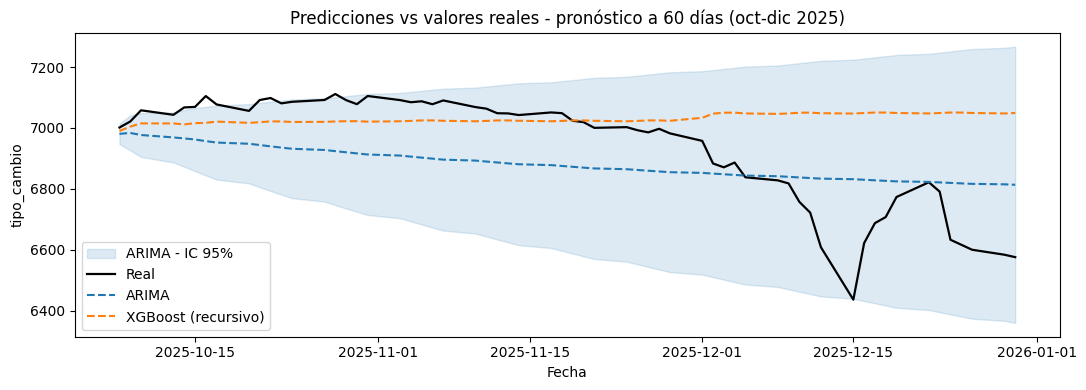

In [7]:
fig, ax = plt.subplots()
ax.fill_between(res[DATE_COL], res["arima_ci_lower"], res["arima_ci_upper"],
                 color="tab:blue", alpha=0.15, label="ARIMA - IC 95%")
ax.plot(res[DATE_COL], res[TARGET_COL], label="Real", color="black", linewidth=1.6)
ax.plot(res[DATE_COL], res["pred_arima"], label="ARIMA", linestyle="--")
ax.plot(res[DATE_COL], res["pred_xgb"], label="XGBoost (recursivo)", linestyle="--")
ax.set_title("Predicciones vs valores reales - pronóstico a 60 días (oct-dic 2025)")
ax.set_xlabel("Fecha"); ax.set_ylabel(TARGET_COL)
ax.legend()
plt.tight_layout()
plt.savefig("../results/03_pred_vs_real.png", dpi=120)
plt.show()

## Cobertura empírica del intervalo de confianza (ARIMA)

Un intervalo de confianza del 95% debería contener el valor real en, aproximadamente, el 95% de los días. Se verifica esto empíricamente en el tramo de test, en vez de asumir que el modelo está bien calibrado solo porque reportó un intervalo.

In [8]:
dentro_ic = ((res[TARGET_COL] >= res["arima_ci_lower"]) & (res[TARGET_COL] <= res["arima_ci_upper"]))
cobertura = dentro_ic.mean() * 100
print(f"Cobertura empírica del IC 95%: {cobertura:.1f}% ({dentro_ic.sum()} de {len(res)} días)")
print("=> " + ("Calibrado (cerca del 95% nominal)" if cobertura >= 90 else "El modelo subestima su propia incertidumbre: el valor real cae fuera del IC más seguido de lo esperado"))

Cobertura empírica del IC 95%: 85.0% (51 de 60 días)
=> El modelo subestima su propia incertidumbre: el valor real cae fuera del IC más seguido de lo esperado


## Comparación de modelos (barras de métricas)

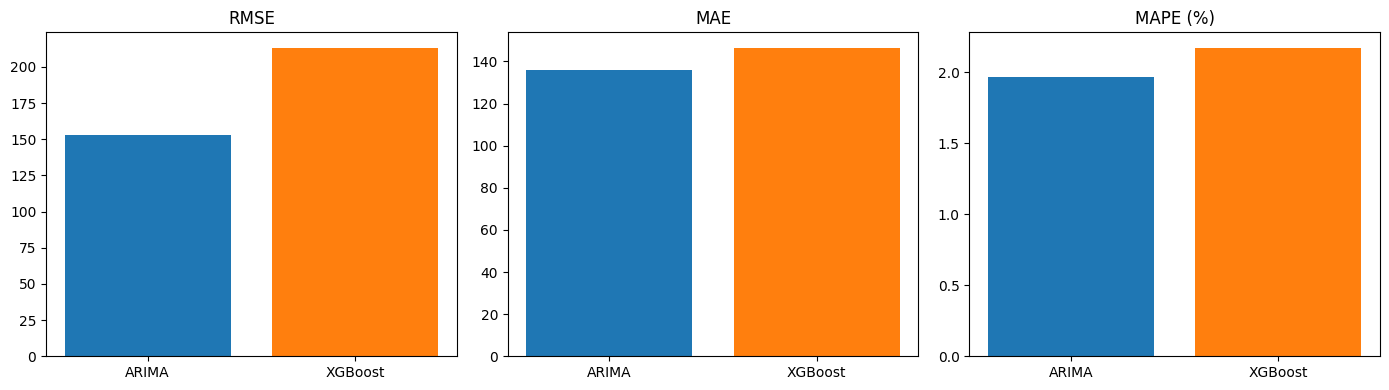

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE (%)"]):
    ax.bar(metrics_df["Modelo"], metrics_df[metric], color=["tab:blue", "tab:orange"])
    ax.set_title(metric)
plt.tight_layout()
plt.savefig("../results/03_comparacion_modelos.png", dpi=120)
plt.show()


## Análisis de residuales

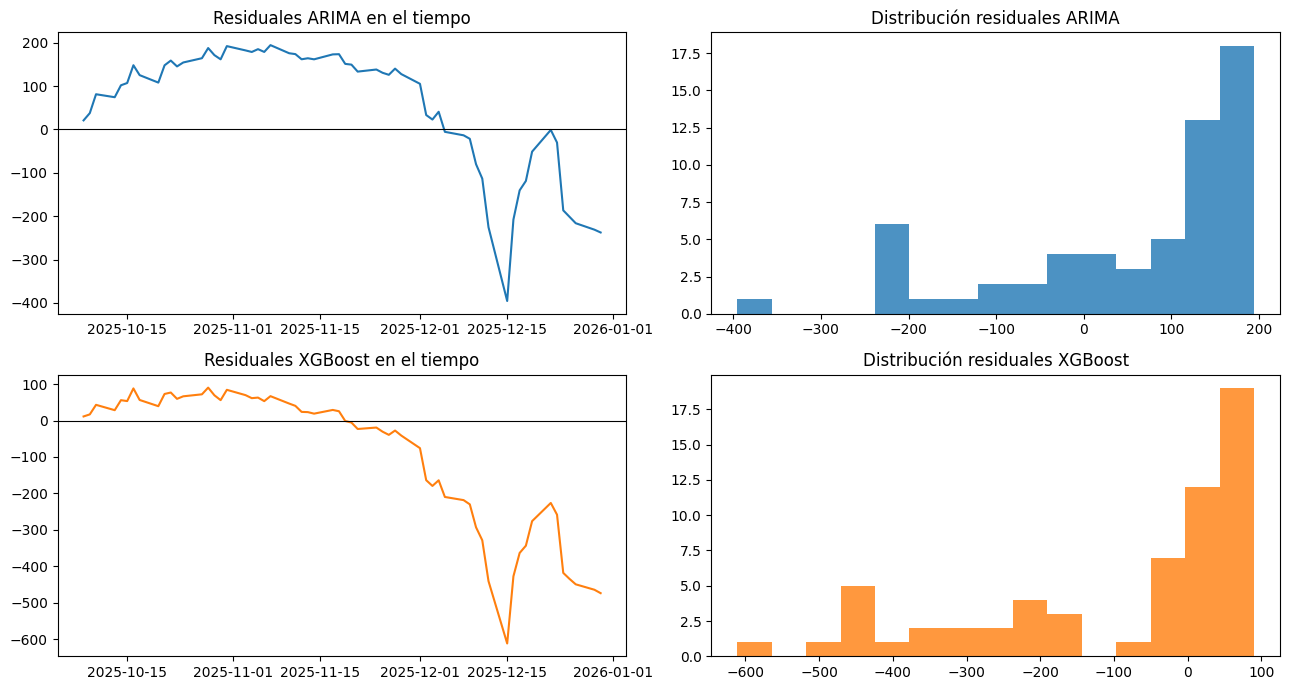

In [10]:
res["resid_arima"] = res[TARGET_COL] - res["pred_arima"]
res["resid_xgb"] = res[TARGET_COL] - res["pred_xgb"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

axes[0, 0].plot(res[DATE_COL], res["resid_arima"], color="tab:blue")
axes[0, 0].axhline(0, color="black", linewidth=0.8)
axes[0, 0].set_title("Residuales ARIMA en el tiempo")

axes[0, 1].hist(res["resid_arima"], bins=15, color="tab:blue", alpha=0.8)
axes[0, 1].set_title("Distribución residuales ARIMA")

axes[1, 0].plot(res[DATE_COL], res["resid_xgb"], color="tab:orange")
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_title("Residuales XGBoost en el tiempo")

axes[1, 1].hist(res["resid_xgb"], bins=15, color="tab:orange", alpha=0.8)
axes[1, 1].set_title("Distribución residuales XGBoost")

plt.tight_layout()
plt.savefig("../results/03_analisis_residuales.png", dpi=120)
plt.show()


In [11]:
print("Media residual ARIMA:", res['resid_arima'].mean().round(2))
print("Media residual XGBoost:", res['resid_xgb'].mean().round(2))
print("\nError absoluto promedio primeros 15 dias vs ultimos 15 dias (¿crece el error con el horizonte?):")
for col, name in [("resid_arima", "ARIMA"), ("resid_xgb", "XGBoost")]:
    primero = res[col].iloc[:15].abs().mean()
    ultimo = res[col].iloc[-15:].abs().mean()
    print(f"  {name}: primeros 15 dias={primero:.1f} | ultimos 15 dias={ultimo:.1f}")

print("\nMejor modelo según RMSE:", metrics_df.loc[metrics_df['RMSE'].idxmin(), 'Modelo'])
print("Mejor modelo según MAPE:", metrics_df.loc[metrics_df['MAPE (%)'].idxmin(), 'Modelo'])


Media residual ARIMA: 53.43
Media residual XGBoost: -94.56

Error absoluto promedio primeros 15 dias vs ultimos 15 dias (¿crece el error con el horizonte?):
  ARIMA: primeros 15 dias=117.4 | ultimos 15 dias=162.6
  XGBoost: primeros 15 dias=55.3 | ultimos 15 dias=386.9

Mejor modelo según RMSE: ARIMA
Mejor modelo según MAPE: ARIMA


## Conclusiones

- El intervalo de confianza del 95% de ARIMA **solo cubrió el valor real en el 85% de los días de test** (51 de 60), por debajo del 95% nominal. El modelo subestima su propia incertidumbre, probablemente porque no anticipa el quiebre de tendencia de 2025 (ver notebook 01) — un intervalo bien calibrado debería ensancharse más ante ese tipo de cambio de régimen.
- Con la corrección metodológica del notebook 02, **ambos modelos pronostican
  el mismo horizonte de 60 días de forma recursiva/estática**, sin usar
  valores reales futuros — la comparación de métricas ahora es válida.
- **ARIMA obtuvo mejores métricas que XGBoost** en este pronóstico a 60 días.
  El error absoluto de XGBoost crece mucho más rápido a lo largo del
  horizonte (de ~55 a ~387 entre los primeros y los últimos 15 días) que el
  de ARIMA (de ~117 a ~163) — reflejo de que el pronóstico recursivo con un
  modelo de árboles acumula y amplifica su propio error paso a paso, mientras
  que ARIMA tiene un comportamiento de reversión a la tendencia más estable
  en pronósticos largos.
- El test de **Ljung-Box** (aplicado correctamente, excluyendo el burn-in del
  filtro de Kalman — ver notebook 02) mostró que los residuales de ARIMA
  **no presentan autocorrelación significativa en el rezago 10** (buen
  ajuste de corto plazo), aunque aparece una señal leve en el rezago 20. No
  es evidencia de una falla grave del modelo, pero sí sugiere que podría
  quedar algo de estructura de más largo plazo sin capturar.
- **Trabajo futuro:** incorporar variables macroeconómicas exógenas (precio
  de la soja, tasa de política monetaria, IPC), evaluar con walk-forward
  validation completo (reentrenando en cada paso en vez de un único
  pronóstico estático/recursivo), o probar modelos de Deep Learning (LSTM).